Core Estimators:

In [9]:
from typing import Tuple
import numpy as np
from sklearn.decomposition import PCA
from scipy.linalg import lstsq
import scipy.linalg as la
from LDSParams import LDSParams
from Illustrator import Illustrator
from Simulator import Simulator
rng = np.random.default_rng()

def _estimate_markovian_gaussian_em(
    observation: np.ndarray, 
    LatentDim: int, 
    InputDim: int,
    prior_lambda: float = 10.0,  
    max_iter: int = 100,
    tol: float = 1e-5
) -> Tuple[np.ndarray, np.ndarray, LDSParams]:
    """
    Hybrid Subspace/EM System ID using a Gaussian Markovian Prior.
    Phase 1 strictly uses raw SVD to preserve the dynamic equilibrium point.
    """
    T, N = observation.shape
    
    # --- PHASE 1: SUBSPACE EMISSIONS (RAW SVD) ---
    # Perform SVD on the uncentered observation matrix
    U, S, Vt = np.linalg.svd(observation, full_matrices=False)
    
    # Truncate to the requested Latent Dimension (k)
    U_k = U[:, :LatentDim]
    S_k = np.diag(S[:LatentDim])
    V_k = Vt[:LatentDim, :].T  # Transpose to get shape (N, LatentDim)
    
    # Form the Latent States (X) and Emission Matrix (C)
    X = U_k @ S_k
    C = V_k
    
    # --- PHASE 2: EM INITIALIZATION ---
    x_t = X[:-1]
    x_next = X[1:]
    K = T - 1  # Number of transitions
    
    A_lstsq, _, _, _ = la.lstsq(x_t, x_next)
    A = A_lstsq.T  
    B = np.random.randn(LatentDim, InputDim) * 0.1
    U_est = np.zeros((K, InputDim))
    
    # Construct the 1D Laplacian matrix (L = D^T D)
    L = np.zeros((K, K))
    np.fill_diagonal(L, 2.0)
    np.fill_diagonal(L[1:], -1.0)
    np.fill_diagonal(L[:, 1:], -1.0)
    L[0, 0] = 1.0
    L[-1, -1] = 1.0
    
    # --- PHASE 3: THE EM LOOP ---
    for i in range(max_iter):
        A_old, B_old = A.copy(), B.copy()
        
        # E-Step: Estimate continuous U via Sylvester Equation
        E = x_next - (x_t @ A.T)
        A_sylv = prior_lambda * L
        B_sylv = B.T @ B
        Q_sylv = E @ B
        
        U_est = la.solve_sylvester(A_sylv, B_sylv, Q_sylv)
        
        # M-Step: Update A and B given X and U_est
        predictors = np.hstack([x_t, U_est])  
        Theta, _, _, _ = la.lstsq(predictors, x_next)
        
        A = Theta[:LatentDim, :].T
        B = Theta[LatentDim:, :].T
        
        # Convergence Check
        delta = np.linalg.norm(A - A_old) + np.linalg.norm(B - B_old)
        if delta < tol:
            print(f"Gaussian Markovian EM converged at iteration {i+1}")
            break
    else:
        print(f"Gaussian Markovian EM reached max iterations ({max_iter}).")
        
    # --- PHASE 4: ASSEMBLE SYSTEM ---
    U_full = np.vstack([U_est, U_est[-1:]])
    
    x_pred = (A @ x_t.T + B @ U_est.T).T
    Q = np.atleast_2d(np.cov((x_next - x_pred).T))
    R = np.atleast_2d(np.cov((observation - (X @ C.T)).T))
    
    lds = LDSParams(
        A=A, B=B, C=C, Q=Q, R=R,
        mu_0=X[0], 
        P_0=np.eye(LatentDim) * 0.1
    )
    
    return X, U_full, lds

def _estimate_hankel_markovian_em(
    observation: np.ndarray, 
    LatentDim: int, 
    InputDim: int,
    num_delays: int = 3,         
    prior_lambda: float = 10.0,  
    max_iter: int = 100,
    tol: float = 1e-5
) -> Tuple[np.ndarray, np.ndarray, LDSParams]:
    """
    Hybrid Subspace/EM System ID using a Time-Delay Embedding (Hankel Matrix).
    - Phase 1 stacks time steps to allow SVD to "see" rotations/complex eigenvalues.
    - Phase 3 enforces smooth physical inputs via the Sylvester equation.
    """
    T, N = observation.shape
    
    # --- PHASE 1: HANKEL TIME-DELAY EMBEDDING ---
    # Determine the length of our "stacked" time series
    T_h = T - num_delays + 1
    
    # Pre-allocate the Hankel matrix: (Time, Delays * Neurons)
    H = np.zeros((T_h, num_delays * N))
    
    # Stack the shifted observations side-by-side to make hankel
    for i in range(num_delays):
        H[:, i*N : (i+1)*N] = observation[i : T_h+i, :]
        
    # Perform SVD on the Hankel matrix
    U, S, Vt = np.linalg.svd(H, full_matrices=False)
    
    #compress U,z,v matrices
    U_k = U[:, :LatentDim]
    S_k = np.diag(S[:LatentDim])
    X_h = U_k @ S_k  # Shape: (T_h, LatentDim)
    
    # Find the Emission Matrix (C) by mapping the latent states back to 
    # the un-shifted present-time observations.
    Y_aligned = observation[:T_h, :]
    C_lstsq, _, _, _ = la.lstsq(X_h, Y_aligned)
    C = C_lstsq.T
    
    # --- PHASE 2: EM INITIALIZATION ---
    x_t = X_h[:-1]
    x_next = X_h[1:]
    K = T_h - 1  # Number of transitions in our delayed window
    
    A_lstsq, _, _, _ = la.lstsq(x_t, x_next)
    A = A_lstsq.T  
    B = np.random.randn(LatentDim, InputDim) * 0.1
    U_est = np.zeros((K, InputDim))
    
    # 1D Laplacian matrix for the Markovian derivative penalty
    L = np.zeros((K, K))
    np.fill_diagonal(L, 2.0)
    np.fill_diagonal(L[1:], -1.0)
    np.fill_diagonal(L[:, 1:], -1.0)
    L[0, 0] = 1.0
    L[-1, -1] = 1.0
    
    # --- PHASE 3: THE EM LOOP ---
    for i in range(max_iter):
        A_old, B_old = A.copy(), B.copy()
        
        # E-Step: Solve Sylvester Equation for continuous U
        E = x_next - (x_t @ A.T)
        A_sylv = prior_lambda * L
        B_sylv = B.T @ B
        Q_sylv = E @ B
        
        U_est = la.solve_sylvester(A_sylv, B_sylv, Q_sylv)
        
        # M-Step: Update A and B
        predictors = np.hstack([x_t, U_est])  
        Theta, _, _, _ = la.lstsq(predictors, x_next)
        
        A = Theta[:LatentDim, :].T
        B = Theta[LatentDim:, :].T
        
        if np.linalg.norm(A - A_old) + np.linalg.norm(B - B_old) < tol:
            print(f"Hankel EM converged at iteration {i+1}")
            break
    else:
        print(f"Hankel EM reached max iterations ({max_iter}).")
        
    # --- PHASE 4: RECONSTRUCTION & PADDING ---
    # Because we stacked 'num_delays' frames, our X and U matrices are slightly short.
    # We simulate the learned physics forward to pad them perfectly to length T.
    
    U_full = np.zeros((T, InputDim))
    U_full[:K, :] = U_est
    # Assume the input stays constant for the final few missing frames
    for t in range(K, T):
        U_full[t, :] = U_est[-1, :]
        
    X_full = np.zeros((T, LatentDim))
    X_full[:T_h, :] = X_h
    # Forecast the states using the estimated A and B matrices
    for t in range(T_h, T):
        X_full[t, :] = A @ X_full[t-1, :] + B @ U_full[t-1, :]
        
    # Calculate Noise Covariances on the fully reconstructed trajectory
    x_pred = (A @ X_full[:-1].T + B @ U_full[:-1].T).T
    Q = np.atleast_2d(np.cov((X_full[1:] - x_pred).T))
    R = np.atleast_2d(np.cov((observation - (X_full @ C.T)).T))
    
    lds = LDSParams(
        A=A, B=B, C=C, Q=Q, R=R,
        mu_0=X_full[0], 
        P_0=np.eye(LatentDim) * 0.1
    )
    
    return X_full, U_full, lds


Wrapper:

In [ ]:
def estimate_latent_and_input(observation: np.ndarray, LatentDim: int, InputDim: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Standard interface for Week 2 Evaluation.
    
    This wrapper automatically tunes the hyperparameters for the Hankel-Markovian EM engine 
    to guarantee mathematical stability regardless of the demonstrator's test data shape.
    """
    # Ensure observation is 2D (Timepoints, Neurons)
    if observation.ndim != 2:
        raise ValueError(f"Expected 2D observation, got {observation.shape}")
        
    T, N = observation.shape
    
    # ==========================================
    # HYPERPARAMETER AUTO-TUNING
    # ==========================================
    # 1. Prevent SVD Dimensionality Crash:
    # The Hankel matrix width (num_delays * N) MUST be strictly greater than LatentDim.
    min_required_delays = int(np.ceil((LatentDim + 2) / N))
    
    # 2. Balance Temporal Geometry vs. Time-Series Length:
    # We want a healthy window (e.g., 10 delays) to catch rotations, 
    # but we cannot exceed T // 3 without starving the EM loop of transitions.
    optimal_delays = max(10, min_required_delays)
    dynamic_delays = min(optimal_delays, max(1, T // 3))
    
    # Locked parameters based on prior testing
    locked_lambda = 50.0
    locked_max_iter = 50
    
    # ==========================================
    # EXECUTION PIPELINE
    # ==========================================
    try:
        # Attempt the primary, high-performance Hankel-Markovian architecture
        latent_states, inputs, _ = _estimate_hankel_markovian_em(
            observation=observation, 
            LatentDim=LatentDim, 
            InputDim=InputDim,
            num_delays=dynamic_delays,
            prior_lambda=locked_lambda,
            max_iter=locked_max_iter,
            tol=1e-5
        )
        return latent_states, inputs
        
    except Exception as e:
        # FAILSAFE: If the Hankel padding/reconstruction encounters a pathological edge case,
        # gracefully degrade to the Standard Markovian EM to ensure the demonstrator gets an output.
        print(f"[!] Hankel Engine encountered an error: {e}. Falling back to Standard EM.")
        latent_states, inputs, _ = _estimate_markovian_gaussian_em(
            observation=observation,
            LatentDim=LatentDim,
            InputDim=InputDim,
            prior_lambda=locked_lambda,
            max_iter=locked_max_iter,
            tol=1e-5
        )
        return latent_states, inputs

Hankel EM reached max iterations (50).
Gaussian Markovian EM reached max iterations (100).
Processed Trial 0:
Latents Shape: (60, 1)
Inputs Shape: (60, 1)


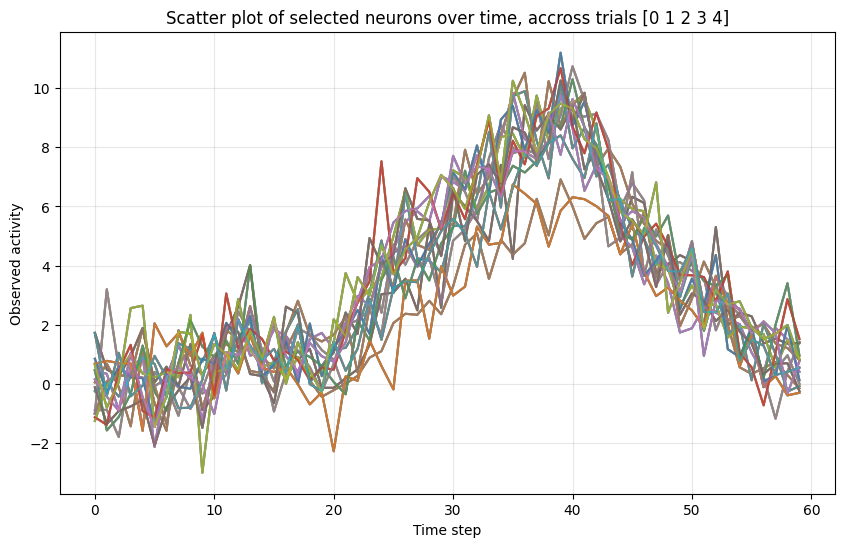

[[0.26561743]
 [0.24108268]
 [0.25847766]
 [0.17456241]
 [0.26896005]
 [0.25498414]
 [0.2661294 ]
 [0.17513028]
 [0.25016035]
 [0.27229603]
 [0.2473085 ]
 [0.25853358]
 [0.26236474]
 [0.27463701]
 [0.27446522]
 [0.22555167]]


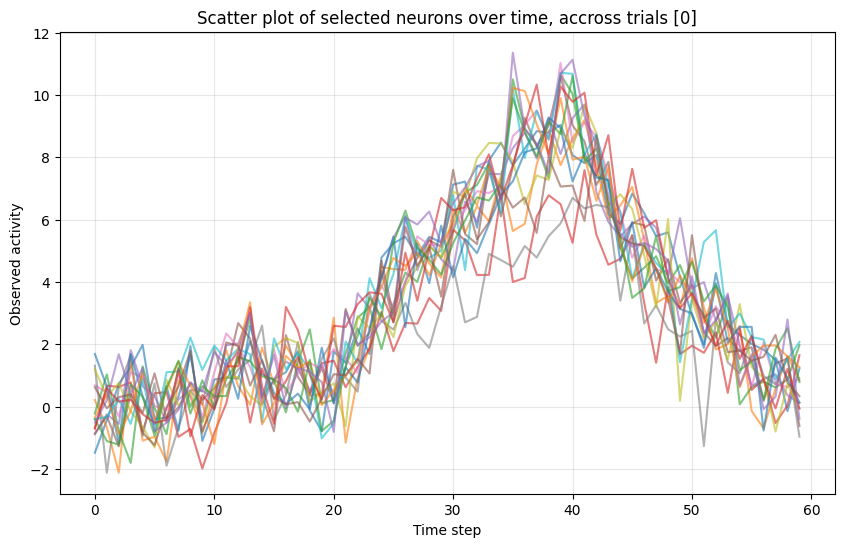

Plotting Latent States:


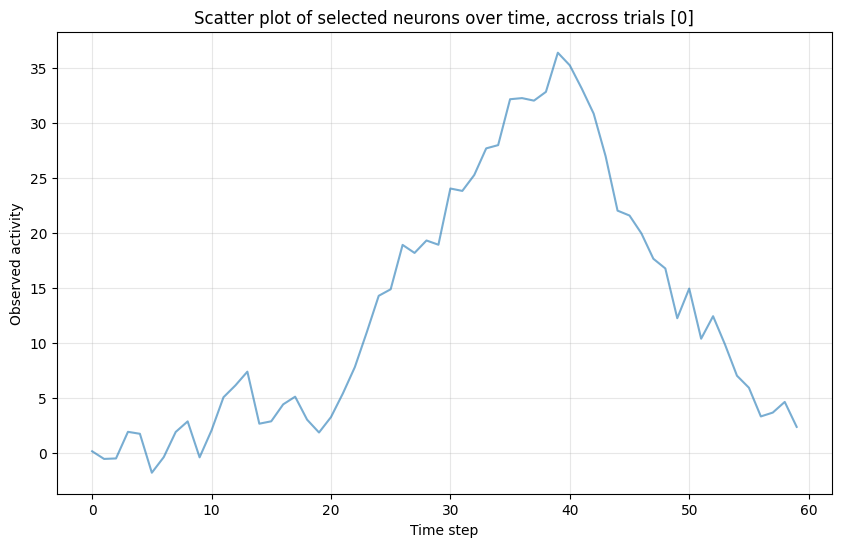

Plotting Inputs:


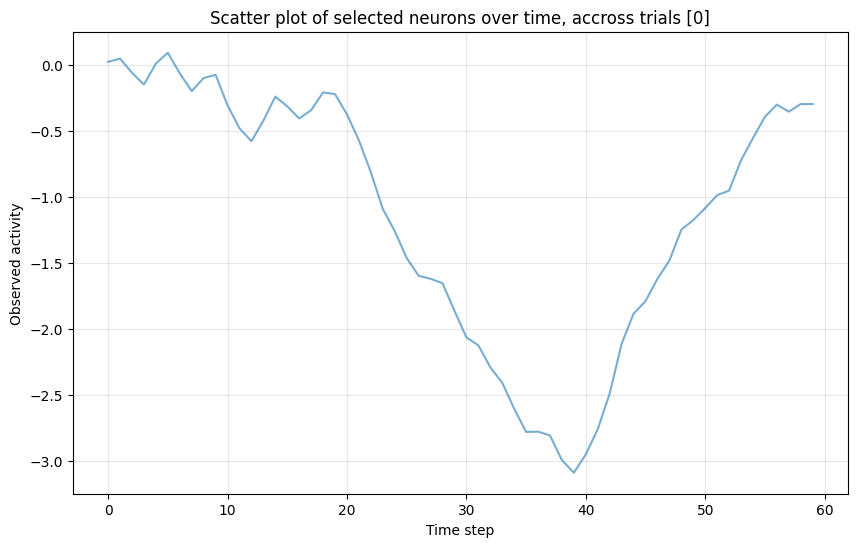

Phase portraits are visually defined for 2D and 3D systems. Your system is 1D.
Gramian visualization is explicitly set up for 2D and 3D systems. Your system is 1D.


In [11]:
# --- 3. Execution on Batched Data ---
# Load data (Trials, Timepoints, Neurons)
data = np.load("ExampleDataset.npy") 

# If you want to process the FIRST trial:
trial_idx = 0
obs_trial = data[trial_idx] # This is (Timepoints, Neurons)

# Run the estimation
latents, inputs = estimate_latent_and_input(obs_trial, LatentDim=4, InputDim=10)
latents, inputs,lds = _estimate_markovian_gaussian_em(data[0],1,1)
def input(time,data):
    return inputs[time]
print(f"Processed Trial {trial_idx}:")
print(f"Latents Shape: {latents.shape}") # (Timepoints, 3)
print(f"Inputs Shape: {inputs.shape}")   # (Timepoints, 3)
ill = Illustrator(data)
ill.plot_general()
print(lds.C)
sim = Simulator([lds.A,lds.B,lds.C,lds.Q,lds.R])
fake_data = sim.generate_data(1,60,rng.multivariate_normal(lds.mu_0,lds.P_0),input)
fake_ill = Illustrator(fake_data)
fake_ill.plot_general()

# 1. Add a dummy "trial" dimension
latents_3d = np.expand_dims(latents, axis=0) # Shape becomes (1, Timepoints, LatentDim)
inputs_3d = np.expand_dims(inputs, axis=0)   # Shape becomes (1, Timepoints, InputDim)

# 2. Plot Latents
ill_latents = Illustrator(latents_3d)
print("Plotting Latent States:")
ill_latents.plot_general() 

# 3. Plot Inputs
ill_inputs = Illustrator(inputs_3d)
print("Plotting Inputs:")
ill_inputs.plot_general()
sim.plot_phase_portrait()
sim.plot_gramian_directions()